# 01 — Data Visualization

Quick sanity checks on the reconstructed DermNet-based dataset used by the
three-stage eczema pipeline. This notebook is pure EDA: **no training**.

Pipeline stages and the class folders each stage reads from:

| Stage | Task | Classes |
|---|---|---|
| 1 | Skin validation | `allSkin` vs `invalid` |
| 2 | Eczema detection | `clearSkin` vs `eczema` |
| 3 | Severity grading | `mild` vs `moderate` vs `severe` |


In [7]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA = Path("data")
SPLITS = ["train", "val", "test"]
CLASSES = ["allSkin", "clearSkin", "eczema", "invalid", "mild", "moderate", "severe"]


## 1. Per-split / per-class image counts

In [8]:
def count_images(split):
    return {c: len(list((DATA / split / c).glob('*'))) for c in CLASSES}

counts = {s: count_images(s) for s in SPLITS}

# Pretty-print table
hdr = f"{'class':<12} " + " ".join(f"{s:>7}" for s in SPLITS) + f"{'total':>8}"
print(hdr)
print("-" * len(hdr))
for c in CLASSES:
    row = [counts[s][c] for s in SPLITS]
    print(f"{c:<12} " + " ".join(f"{n:>7}" for n in row) + f"{sum(row):>8}")
print("-" * len(hdr))
totals = [sum(counts[s][c] for c in CLASSES) for s in SPLITS]
print(f"{'TOTAL':<12} " + " ".join(f"{n:>7}" for n in totals) + f"{sum(totals):>8}")


class          train     val    test   total
--------------------------------------------
allSkin         1828     391     393    2612
clearSkin        842     180     182    1204
eczema           985     211     212    1408
invalid         1680     360     360    2400
mild             275      58      60     393
moderate         448      96      97     641
severe           210      45      45     300
--------------------------------------------
TOTAL           6268    1341    1349    8958


## 2. Bar chart of class sizes (train split)

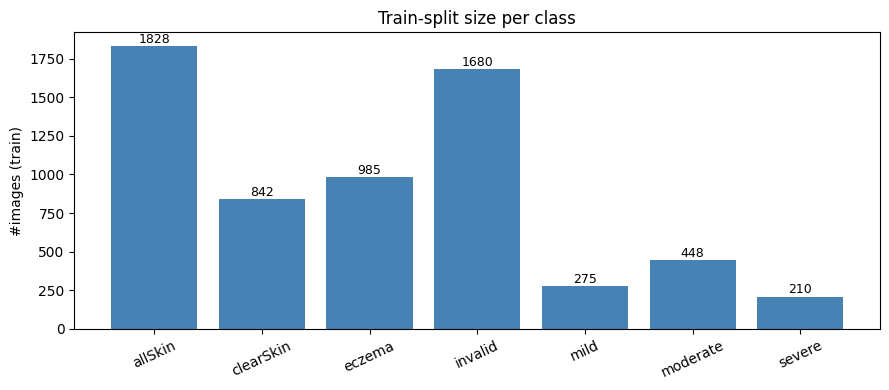

In [9]:
train_counts = counts['train']
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(train_counts.keys(), train_counts.values(), color='steelblue')
ax.set_ylabel('#images (train)')
ax.set_title('Train-split size per class')
for i, (k, v) in enumerate(train_counts.items()):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 3. Sample image grid

Three random samples per class from the train split. Useful to verify the
filename-to-class mapping built in `build_dataset.py` actually produced
visually distinct groups.

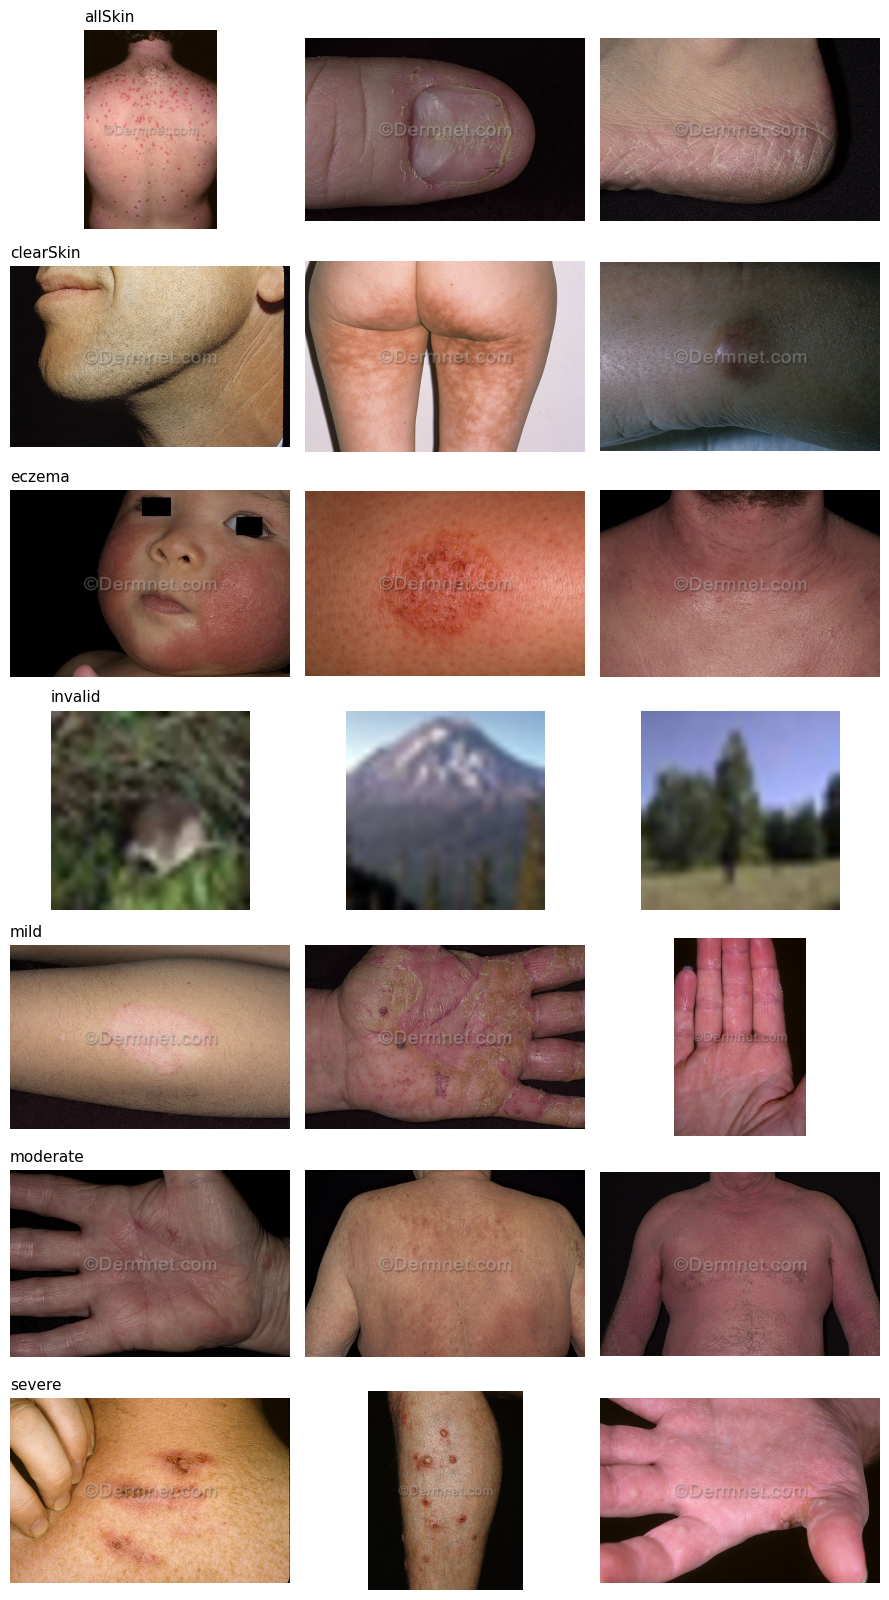

In [10]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, len(CLASSES) * 2.3))
for row, cls in enumerate(CLASSES):
    files = list((DATA / 'train' / cls).glob('*'))
    picks = rng.choice(files, size=min(3, len(files)), replace=False)
    for col, f in enumerate(picks):
        img = Image.open(f).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11)
    axes[row, 0].set_title(cls, loc='left', fontsize=11)
plt.tight_layout()
plt.show()


## 4. Image dimension statistics

In [11]:
def dim_stats(split, cls, n_sample=60):
    files = list((DATA / split / cls).glob('*'))
    rng = np.random.default_rng(1)
    picks = rng.choice(files, size=min(n_sample, len(files)), replace=False)
    dims = [Image.open(p).size for p in picks]
    w = [d[0] for d in dims]; h = [d[1] for d in dims]
    return {
        'w_min': min(w), 'w_max': max(w), 'w_mean': int(np.mean(w)),
        'h_min': min(h), 'h_max': max(h), 'h_mean': int(np.mean(h)),
        'n': len(picks),
    }

print(f"{'class':<12} {'w_min':>6} {'w_max':>6} {'w_mean':>7}   "
      f"{'h_min':>6} {'h_max':>6} {'h_mean':>7}   {'n':>4}")
print('-' * 72)
for c in CLASSES:
    s = dim_stats('train', c)
    print(f"{c:<12} {s['w_min']:>6} {s['w_max']:>6} {s['w_mean']:>7}   "
          f"{s['h_min']:>6} {s['h_max']:>6} {s['h_mean']:>7}   {s['n']:>4}")


class         w_min  w_max  w_mean    h_min  h_max  h_mean      n
------------------------------------------------------------------------
allSkin         456    720     662      464    720     535     60
clearSkin       462    720     654      426    720     544     60
eczema          466    720     646      458    720     554     60
invalid         224    224     224      224    224     224     60
mild            475    720     664      469    720     536     60
moderate        467    720     655      464    720     541     60
severe          464    720     622      464    720     581     60


## 5. Stage-level aggregation

How many images each pipeline stage sees after its class selection.

In [12]:
stage_map = {
    'Stage 1 (skin validation)': ['allSkin', 'invalid'],
    'Stage 2 (eczema detection)': ['clearSkin', 'eczema'],
    'Stage 3 (severity)': ['mild', 'moderate', 'severe'],
}
for stage, classes in stage_map.items():
    print(stage)
    for c in classes:
        tr = counts['train'][c]; va = counts['val'][c]; te = counts['test'][c]
        print(f"  {c:<12}  train {tr:>4}  val {va:>4}  test {te:>4}")
    total = sum(counts['train'][c] + counts['val'][c] + counts['test'][c] for c in classes)
    print(f"  total: {total}\n")


Stage 1 (skin validation)
  allSkin       train 1828  val  391  test  393
  invalid       train 1680  val  360  test  360
  total: 5012

Stage 2 (eczema detection)
  clearSkin     train  842  val  180  test  182
  eczema        train  985  val  211  test  212
  total: 2612

Stage 3 (severity)
  mild          train  275  val   58  test   60
  moderate      train  448  val   96  test   97
  severe        train  210  val   45  test   45
  total: 1334

